## NIMOハンズオン (関数の最適化)

In [1]:
import sys
sys.path.append('..')
import nimo

### AIとロボットのサイクルの回数を設定

In [2]:
CyclesNum = 31

### 目的関数の次元を設定

In [3]:
ObjectivesNum = 1

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [4]:
candidates_file = "./search_space_physbo.csv"

proposals_file = "./proposals_physbo.csv"

### 結果を格納する場所を作成

In [5]:
res_history = nimo.history(input_file = candidates_file,
                             num_objectives = ObjectivesNum)

### 最適化計算

In [6]:
for K in range(CyclesNum):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = candidates_file,
                       output_file = proposals_file,
                       num_objectives = ObjectivesNum,
                       num_proposals = 15,
                       re_seed = 111)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    #PHYSBO: ベイズ最適化
    #BLOX: 無目的探索
    #PDC: 相図探索
    #RE: ランダム
    else:
        nimo.selection(method = "PHYSBO",
                       input_file = candidates_file,
                       output_file = proposals_file,
                       num_objectives = ObjectivesNum,
                       num_proposals = 15,
                       sample_mode=nimo.Mode.conservative,
                       use_dpp=False,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    #今回は，inputfile.txtファイルを作成するだけのモジュール
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = proposals_file,
                                         input_folder = "./").perform()


    #実験終了後，測定データを解析し，目的関数をアップデートする
    #今回は，関数値を計算し，目的関数とするanalysis_output_functions.pyを利用する
    import analysis_output_functions_SO_styblinski_tang
    analysis_output_functions_SO_styblinski_tang.ORIGINAL(input_file = proposals_file,
                                       output_file = candidates_file,
                                       num_objectives = ObjectivesNum,
                                       output_folder = "./data").perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = candidates_file,
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = candidates_file,
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = "./data/fig")

    #結果の相図を作成するモジュールを読み出す
    #if K % 5 == 0:
    #    import time
    #    time.sleep(1)
    #    nimo.visualization.plot_phase_diagram.plot(input_file = candidates_file,
    #                                               fig_folder = "./fig")


Start selection of proposals by RE!
Proposals
###
number = 1
actions =  3485
proposal =  [ 3.6 -1.6]
###
###
number = 2
actions =  5176
proposal =  [2.7 0.2]
###
###
number = 3
actions =  8092
proposal =  [4.3 3.1]
###
###
number = 4
actions =  3181
proposal =  [ 3.2 -1.9]
###
###
number = 5
actions =  6514
proposal =  [-3.6  1.6]
###
###
number = 6
actions =  6831
proposal =  [-1.9  1.9]
###
###
number = 7
actions =  2779
proposal =  [ 3.  -2.3]
###
###
number = 8
actions =  3172
proposal =  [ 2.3 -1.9]
###
###
number = 9
actions =  6908
proposal =  [-4.2  2. ]
###
###
number = 10
actions =  9160
proposal =  [1.1 4.2]
###
###
number = 11
actions =  3763
proposal =  [ 1.4 -1.3]
###
###
number = 12
actions =  3003
proposal =  [-4.7 -2. ]
###
###
number = 13
actions =  7585
proposal =  [3.6 2.6]
###
###
number = 14
actions =  6819
proposal =  [-3.1  1.9]
###
###
number = 15
actions =  6283
proposal =  [3.4 1.3]
###
Finish selection of proposals!
Start preparation input!
Finish preparatio

### 目的関数の推移を出力

In [13]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = "./data/fig")

In [28]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [15]:
import csv
X = []
with open(candidates_file, 'r', newline='', encoding='utf-8') as csvfile:
    reader = csv.reader(csvfile)
    # ヘッダー行がある場合はスキップ
    header = next(reader)
    
    # 各行から1列目と2列目を取得
    for row in reader:
        # 行が空でないことを確認（場合によっては不要）
        if row:
            X.append([float(e) for e in row[0:2]])

In [16]:
def func(e):
    return e**4 - 16 * e**2 + 5 * e

y = []
for x in X:
    y.append(-(func(x[0]) + func(x[1])) / 2)

In [17]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity


(0.0, 0.1)

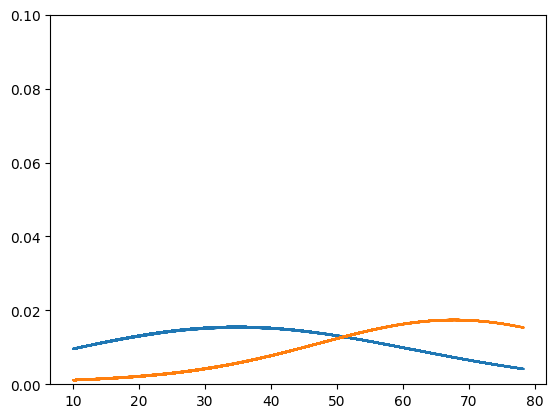

In [19]:
y = np.array(y)
y_large = y[y>10]

kde = KernelDensity(kernel='gaussian', bandwidth=20).fit(np.array(y_large).reshape(-1, 1))
score = kde.score_samples(np.array(y_large).reshape((-1, 1)))
kde = KernelDensity(kernel='gaussian', bandwidth=20).fit(np.array(tmp).reshape(-1, 1))
score_nts = kde.score_samples(np.array(y_large).reshape((-1, 1)))
plt.plot(y_large, np.exp(score))
plt.plot(y_large, np.exp(score_nts))
plt.ylim(0, 0.1)

In [36]:
tmp = np.array(tmp)
sum(tmp > 5)

441

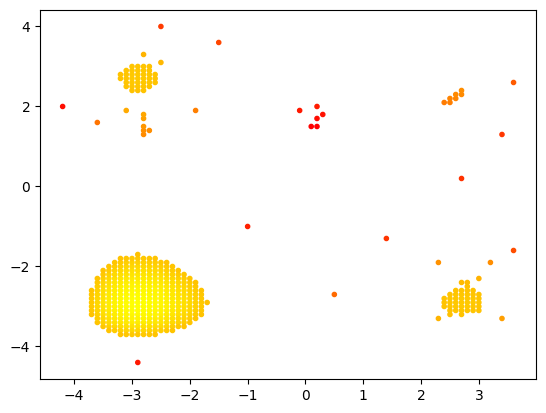

In [38]:
th = 5
plt.scatter(X_tmp[tmp>th].T[0], X_tmp[tmp>th].T[1], c=tmp[tmp>th], cmap='autumn', marker='.')